In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Load your datasets
price = pd.read_csv("C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_price.csv", parse_dates=["Date"])
stock = pd.read_csv("C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_stock.csv", parse_dates=["Date"])
precip = pd.read_csv("C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/precipitation.csv", parse_dates=["Date"])
temp = pd.read_csv("C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/temperature.csv", parse_dates=["Date"])

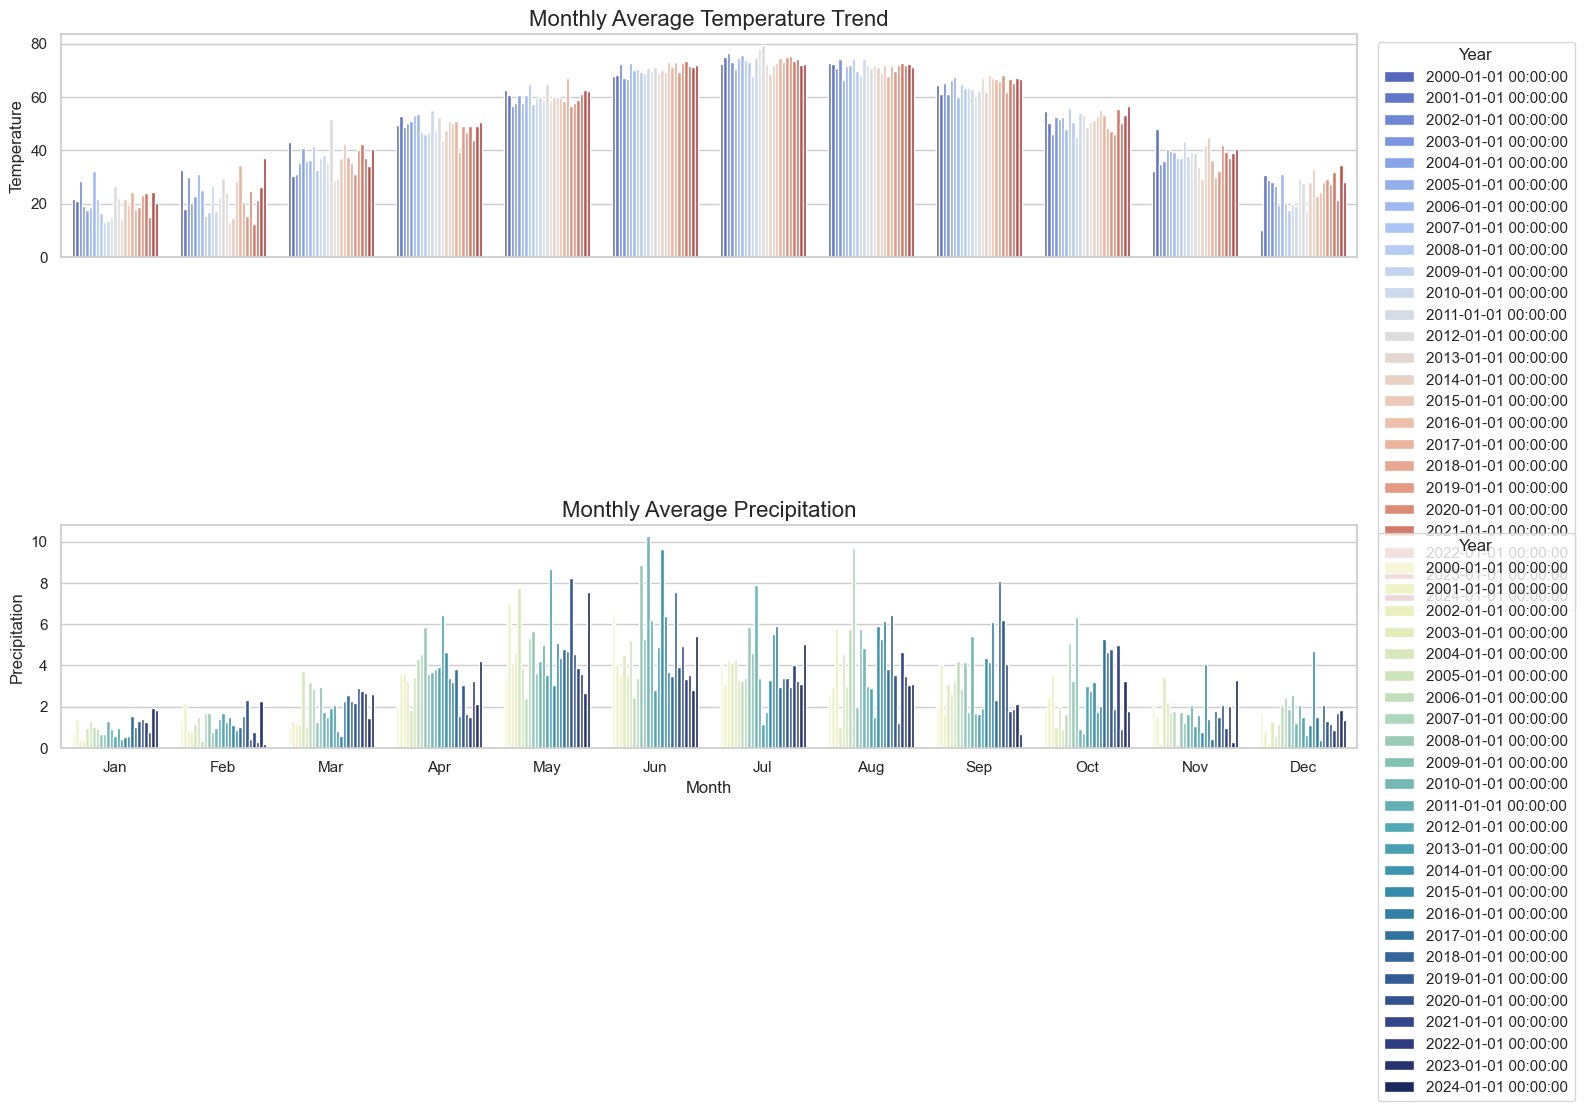

In [25]:
def melt_and_prepare(df, value_name):
    df_melted = df.melt(id_vars='Date', var_name='Month', value_name=value_name)
    df_melted['Month'] = pd.Categorical(df_melted['Month'],
                                        categories=['Jan','Feb','Mar','Apr','May','Jun',
                                                    'Jul','Aug','Sep','Oct','Nov','Dec'],
                                        ordered=True)
    return df_melted

# Melt both into long format
temp_long = melt_and_prepare(temp, 'Temperature')
prec_long = melt_and_prepare(precip, 'Precipitation')

# Set plot style
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Temperature Plot
sns.barplot(data=temp_long, x='Month', y='Temperature', hue='Date', palette='coolwarm', ax=axes[0])
axes[0].set_title('Monthly Average Temperature Trend', fontsize=16)
axes[0].legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left')

# Precipitation Plot
sns.barplot(data=prec_long, x='Month', y='Precipitation', hue='Date', palette='YlGnBu', ax=axes[1])
axes[1].set_title('Monthly Average Precipitation', fontsize=16)
axes[1].legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()


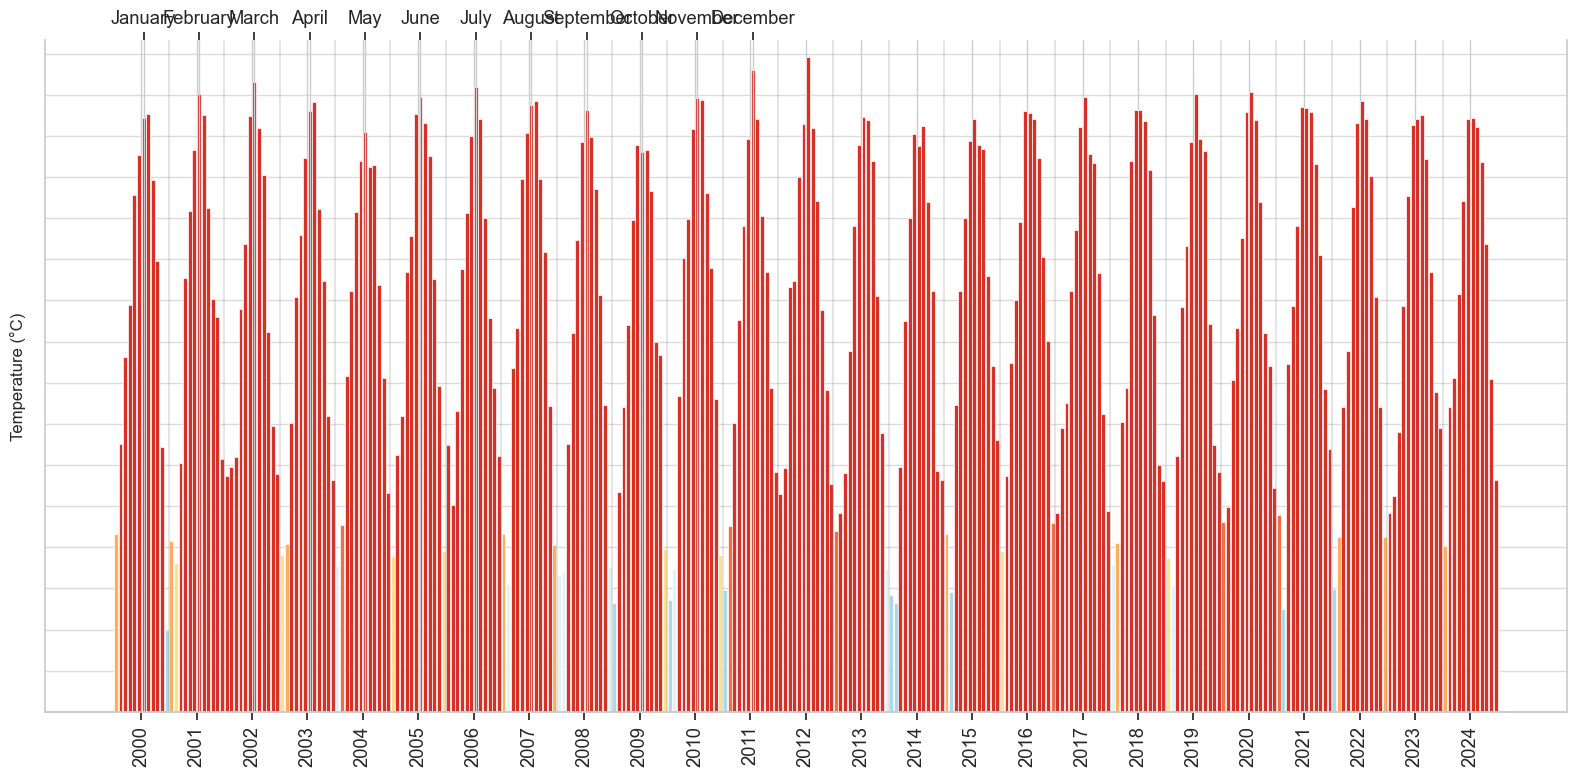

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns
from calendar import month_abbr

# Set the visual style for a clean, elegant look
plt.style.use('ggplot')
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Read the CSV file
df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/temperature.csv')

# Create month names for columns (assuming the format matches your example)
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

# Reshape data from wide to long format for easier plotting
df_long = pd.melt(df, id_vars=['Date'], 
                 value_vars=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
                 var_name='Month', value_name='Temperature')

# Create a mapping for month order
month_order = {month: i for i, month in enumerate(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])}
df_long['MonthNum'] = df_long['Month'].map(month_order)

# Sort by Date and MonthNum
df_long = df_long.sort_values(['Date', 'MonthNum'])

# Create color mapping based on temperature ranges
def get_temp_color(temp):
    if temp < 5:
        return '#4575b4'  # Dark blue for very cold
    elif temp < 10:
        return '#74add1'  # Blue for cold
    elif temp < 15:
        return '#abd9e9'  # Light blue for cool
    elif temp < 18:
        return '#e0f3f8'  # Very light blue for mild cool
    elif temp < 20:
        return '#fee090'  # Light orange for mild warm
    elif temp < 22:
        return '#fdae61'  # Orange for warm
    elif temp < 24:
        return '#f46d43'  # Dark orange for hot
    else:
        return '#d73027'  # Red for very hot

# Apply color mapping
df_long['Color'] = df_long['Temperature'].apply(get_temp_color)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(16, 8))

# Generate x positions (evenly spaced)
unique_years = df['Date'].unique()
unique_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
width = 0.85  # Bar width

# Create bars with custom colors
bars = ax.bar(range(len(df_long)), df_long['Temperature'], width=width, color=df_long['Color'], 
              edgecolor='white', linewidth=0.5)

# Set x-axis labels and ticks
ax.set_xticks(np.arange(0, len(df_long), 12) + 5.5)  # Position ticks between years
ax.set_xticklabels(unique_years, rotation=90)

# Add a secondary x-axis for month labels
ax2 = ax.twiny()
month_positions = np.arange(6, 6 + 12 * len(unique_years), 12)[:12]  # Position for first year's months
ax2.set_xticks(month_positions)
ax2.set_xticklabels(months)
ax2.set_xlim(ax.get_xlim())

# Clean up the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Set y-axis properties
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.yaxis.grid(True, linestyle='-', alpha=0.7)
ax.set_axisbelow(True)

# Add subtle year separators
for i in range(len(unique_years) - 1):
    ax.axvline(x=(i+1)*12 - 0.5, color='gray', linestyle='-', alpha=0.2)

# Create nicer y-axis with 5-unit intervals
max_temp = df_long['Temperature'].max()
y_ticks = np.arange(0, max_temp + 5, 5)
ax.set_yticks(y_ticks)
ax.set_ylim(0, max_temp + 2)

# Remove ax2 labels to avoid confusion
ax2.set_yticklabels([])
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('temperature_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

Successfully loaded data with shape: (25, 13)


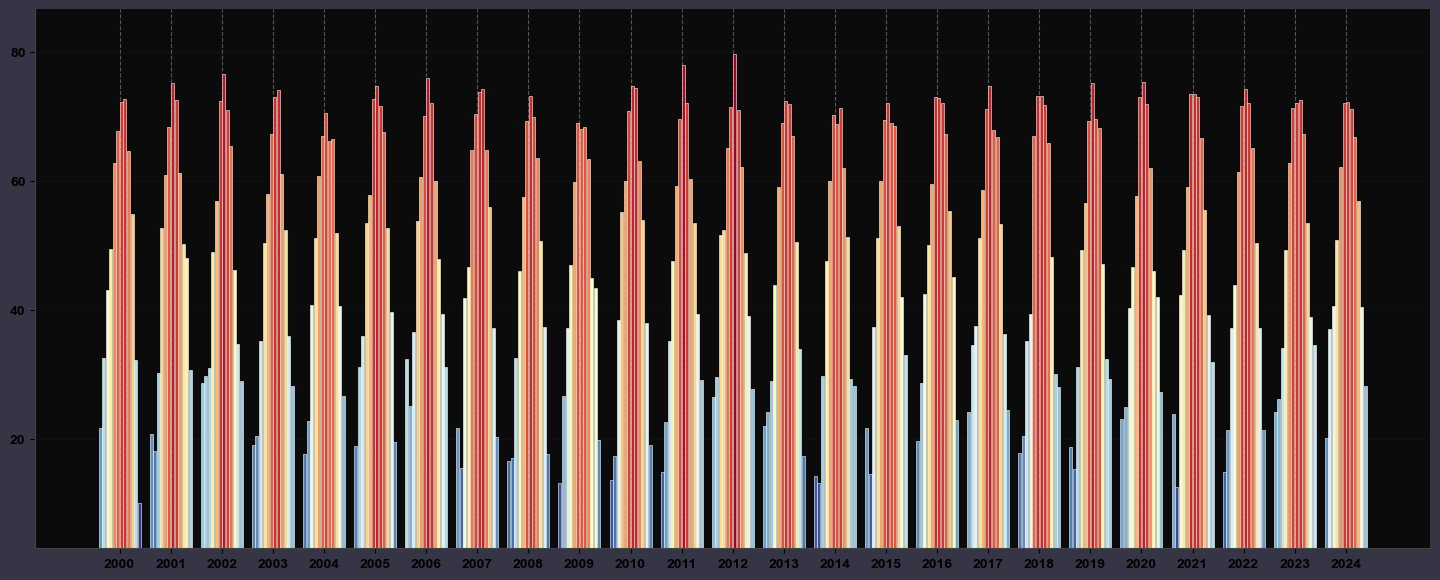

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

# Set font and figure parameters for a more elegant look
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'bold'  # Make all fonts bolder
plt.rcParams['axes.labelsize'] = 12  # Larger label size
plt.rcParams['axes.titlesize'] = 16  # Larger title size
plt.rcParams['xtick.labelsize'] = 10  # Larger tick labels
plt.rcParams['ytick.labelsize'] = 10  # Larger tick labels
plt.rcParams['axes.labelcolor'] = 'black'  # Darker label color
plt.rcParams['xtick.color'] = 'black'  # Darker tick color
plt.rcParams['ytick.color'] = 'black'  # Darker tick color

# Read the temperature data
try:
    df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/temperature.csv')
    print(f"Successfully loaded data with shape: {df.shape}")
except Exception as e:
    print(f"Error reading CSV: {e}")
    # Create sample data if there's an issue
    data = {
        'Date': [2000, 2001, 2002],
        'Jan': [21.6, 20.8, 28.6],
        'Feb': [32.5, 18.1, 29.8],
        'Mar': [43.1, 30.2, 31.0],
        'Apr': [49.4, 52.7, 48.9],
        'May': [62.8, 60.9, 56.8],
        'Jun': [67.7, 68.3, 72.4],
        'Jul': [72.2, 75.1, 76.5],
        'Aug': [72.7, 72.5, 70.9],
        'Sep': [64.6, 61.2, 65.3],
        'Oct': [54.8, 50.2, 46.2],
        'Nov': [32.2, 48.0, 34.7],
        'Dec': [10.0, 30.7, 28.9]
    }
    df = pd.DataFrame(data)

# Get the column that contains years and months
year_column = df.columns[0]  # First column (usually "Date")
months = df.columns[1:].tolist()  # All other columns are months

# Create a figure with a better aspect ratio, slightly larger
fig, ax = plt.subplots(figsize=(18, 7))

# Calculate the min and max temperatures for color scaling
all_temps = []
for _, row in df.iterrows():
    all_temps.extend([row[month] for month in months])
min_temp = min(all_temps)
max_temp = max(all_temps)

# Create a custom colormap from blue to red
colors = ["#313695", "#4575b4", "#74add1", "#abd9e9", "#e0f3f8", 
          "#ffffbf", "#fee090", "#fdae61", "#f46d43", "#d73027", "#a50026"]
cmap = mcolors.LinearSegmentedColormap.from_list("temperature", colors, N=256)
norm = mcolors.Normalize(vmin=min_temp, vmax=max_temp)

# Create x positions for bars with better spacing
total_years = len(df[year_column])
year_width = len(months) * 1.2  # Adjust this for spacing between years
bar_width = 0.85  # Slightly wider bars

bar_positions = []
bar_heights = []
bar_colors = []
x_tick_positions = []
x_tick_labels = []

# Process data and create positions
for idx, year in enumerate(df[year_column]):
    year_start_pos = idx * year_width
    x_tick_positions.append(year_start_pos + (len(months) - 1) / 2)
    x_tick_labels.append(str(year))
    
    for month_idx, month in enumerate(months):
        pos = year_start_pos + month_idx
        temp = df.iloc[idx][month]
        
        bar_positions.append(pos)
        bar_heights.append(temp)
        bar_colors.append(cmap(norm(temp)))

# Create the bars
bars = ax.bar(bar_positions, bar_heights, width=bar_width, color=bar_colors, 
              edgecolor='white', linewidth=0.4)

# Set x-axis ticks for years - make them less cluttered
# Only show a subset of years if there are many
if total_years > 15:
    step = max(1, total_years // 15)
    display_indices = range(0, total_years, step)
    display_positions = [x_tick_positions[i] for i in display_indices]
    display_labels = [x_tick_labels[i] for i in display_indices]
else:
    display_positions = x_tick_positions
    display_labels = x_tick_labels

ax.set_xticks(display_positions)
ax.set_xticklabels(display_labels, fontweight='bold', color='black')

# As requested, remove the month labels at the top
# (Not creating the secondary x-axis)

# Clean up the plot
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Set y-axis properties with more elegant scaling
y_padding = (max_temp - min_temp) * 0.1
y_min = max(0, min_temp - y_padding)
y_max = max_temp + y_padding
y_range = y_max - y_min

# Create nice round tick intervals
if y_range <= 25:
    tick_interval = 5
elif y_range <= 50:
    tick_interval = 10
else:
    tick_interval = 20

y_ticks = np.arange(
    np.floor(y_min / tick_interval) * tick_interval,
    np.ceil(y_max / tick_interval) * tick_interval + 0.1, 
    tick_interval
)
ax.set_yticks(y_ticks)
ax.set_ylim(y_min, y_max)

# Add subtle gridlines only on y-axis
ax.yaxis.grid(True, linestyle='-', alpha=0.15, color='#333333')
ax.set_axisbelow(True)

# Remove the colorbar as requested

Successfully loaded data with shape: (25, 13)


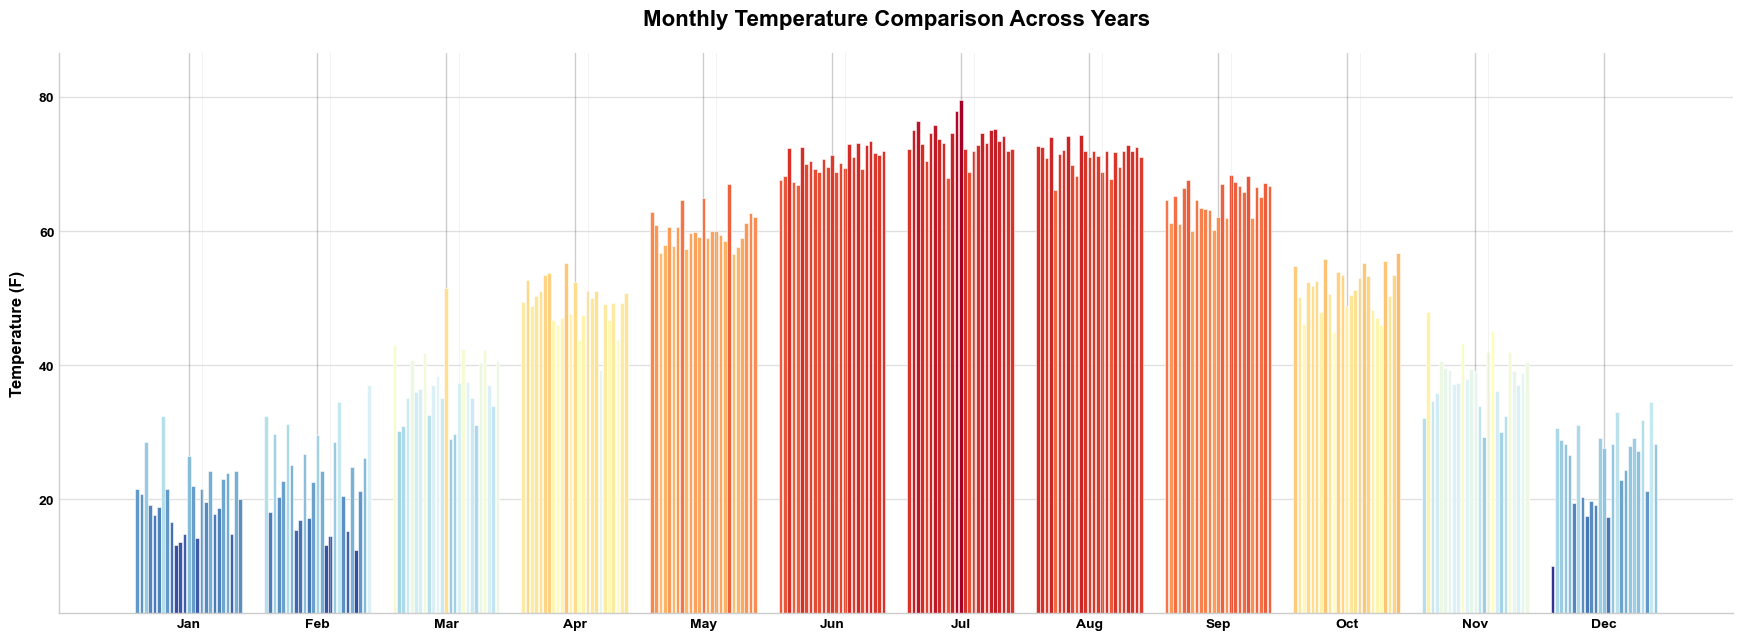

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Set font and figure parameters for a more elegant look
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# Read the temperature data
try:
    df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/temperature.csv')
    print(f"Successfully loaded data with shape: {df.shape}")
except Exception as e:
    print(f"Error reading CSV: {e}")
    # Create sample data if there's an issue
    data = {
        'Date': [2000, 2001, 2002],
        'Jan': [21.6, 20.8, 28.6],
        'Feb': [32.5, 18.1, 29.8],
        'Mar': [43.1, 30.2, 31.0],
        'Apr': [49.4, 52.7, 48.9],
        'May': [62.8, 60.9, 56.8],
        'Jun': [67.7, 68.3, 72.4],
        'Jul': [72.2, 75.1, 76.5],
        'Aug': [72.7, 72.5, 70.9],
        'Sep': [64.6, 61.2, 65.3],
        'Oct': [54.8, 50.2, 46.2],
        'Nov': [32.2, 48.0, 34.7],
        'Dec': [10.0, 30.7, 28.9]
    }
    df = pd.DataFrame(data)

# Get the column that contains years and months
year_column = df.columns[0]  # First column (usually "Date")
months = df.columns[1:].tolist()  # All other columns are months

# Create a figure with a better aspect ratio
fig, ax = plt.subplots(figsize=(18, 7))

# Calculate the min and max temperatures for color scaling
all_temps = []
for _, row in df.iterrows():
    all_temps.extend([row[month] for month in months])
min_temp = min(all_temps)
max_temp = max(all_temps)

# Create a custom colormap from blue to red
colors = ["#313695", "#4575b4", "#74add1", "#abd9e9", "#e0f3f8", 
          "#ffffbf", "#fee090", "#fdae61", "#f46d43", "#d73027", "#a50026"]
cmap = mcolors.LinearSegmentedColormap.from_list("temperature", colors, N=256)
norm = mcolors.Normalize(vmin=min_temp, vmax=max_temp)

# Create x positions for bars - now grouped by month
total_months = len(months)
years = df[year_column].tolist()
total_years = len(years)
month_width = total_years * 1.2  # Spacing between month groups
bar_width = 0.85

bar_positions = []
bar_heights = []
bar_colors = []
x_tick_positions = []
x_tick_labels = []

# Process data and create positions - now grouped by month instead of year
for month_idx, month in enumerate(months):
    month_start_pos = month_idx * month_width
    x_tick_positions.append(month_start_pos + (total_years - 1) / 2)
    x_tick_labels.append(month)
    
    for year_idx, year in enumerate(years):
        pos = month_start_pos + year_idx
        temp = df.loc[df[year_column] == year, month].values[0]
        
        bar_positions.append(pos)
        bar_heights.append(temp)
        bar_colors.append(cmap(norm(temp)))

# Create the bars
bars = ax.bar(bar_positions, bar_heights, width=bar_width, color=bar_colors, 
              edgecolor='white', linewidth=0.4)

# Set x-axis ticks for months
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, fontweight='bold', color='black')

# Add small year labels inside each month group
if total_years <= 8:  # Only add year labels if there aren't too many years
    for month_idx, month in enumerate(months):
        for year_idx, year in enumerate(years):
            pos = month_idx * month_width + year_idx
            ax.text(pos, -2, str(year), ha='center', va='top', 
                   fontsize=7, alpha=0.7, rotation=90)

# Clean up the plot
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Set y-axis properties
y_padding = (max_temp - min_temp) * 0.1
y_min = max(0, min_temp - y_padding)
y_max = max_temp + y_padding
y_range = y_max - y_min

# Create nice round tick intervals
if y_range <= 25:
    tick_interval = 5
elif y_range <= 50:
    tick_interval = 10
else:
    tick_interval = 20

y_ticks = np.arange(
    np.floor(y_min / tick_interval) * tick_interval,
    np.ceil(y_max / tick_interval) * tick_interval + 0.1, 
    tick_interval
)
ax.set_yticks(y_ticks)
ax.set_ylim(y_min, y_max)

# Add subtle gridlines only on y-axis
ax.yaxis.grid(True, linestyle='-', alpha=0.15, color='#333333')
ax.set_axisbelow(True)

# Add slight visual separation between month groups
for i in range(total_months - 1):
    separator_pos = (i + 1) * month_width - month_width/2
    ax.axvline(x=separator_pos, color='#dddddd', linestyle='-', alpha=0.5, linewidth=0.5)

# Add a title
plt.title('Monthly Temperature Comparison Across Years', fontsize=16, pad=20, fontweight='bold', color='black')

# Set y-axis label
ax.set_ylabel('Temperature (F)', labelpad=10, fontsize=12, fontweight='bold', color='black')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.98)

# Save with higher quality
plt.savefig('monthly_temperature_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Successfully loaded data with shape: (25, 13)


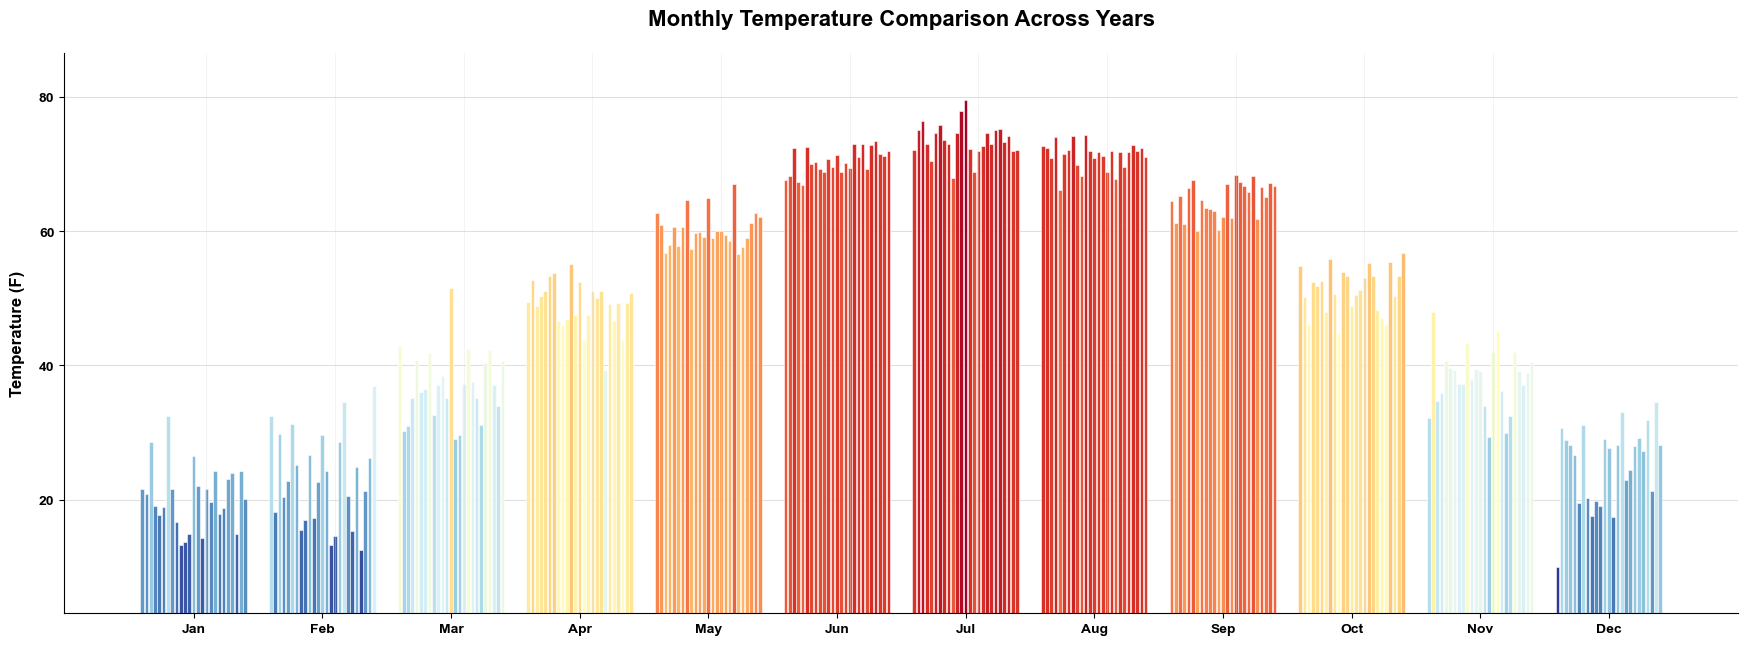

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

plt.style.use('default')  # Resets to default (white background)

# Set font and figure parameters for a more elegant look
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# Read the temperature data
try:
    df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/temperature.csv')
    print(f"Successfully loaded data with shape: {df.shape}")
except Exception as e:
    print(f"Error reading CSV: {e}")
    # Create sample data if there's an issue
    data = {
        'Date': [2000, 2001, 2002],
        'Jan': [21.6, 20.8, 28.6],
        'Feb': [32.5, 18.1, 29.8],
        'Mar': [43.1, 30.2, 31.0],
        'Apr': [49.4, 52.7, 48.9],
        'May': [62.8, 60.9, 56.8],
        'Jun': [67.7, 68.3, 72.4],
        'Jul': [72.2, 75.1, 76.5],
        'Aug': [72.7, 72.5, 70.9],
        'Sep': [64.6, 61.2, 65.3],
        'Oct': [54.8, 50.2, 46.2],
        'Nov': [32.2, 48.0, 34.7],
        'Dec': [10.0, 30.7, 28.9]
    }
    df = pd.DataFrame(data)

# Get the column that contains years and months
year_column = df.columns[0]  # First column (usually "Date")
months = df.columns[1:].tolist()  # All other columns are months

# Create a figure with a better aspect ratio
fig, ax = plt.subplots(figsize=(18, 7))

# Calculate the min and max temperatures for color scaling
all_temps = []
for _, row in df.iterrows():
    all_temps.extend([row[month] for month in months])
min_temp = min(all_temps)
max_temp = max(all_temps)

# Create a custom colormap from blue to red
colors = ["#313695", "#4575b4", "#74add1", "#abd9e9", "#e0f3f8", 
          "#ffffbf", "#fee090", "#fdae61", "#f46d43", "#d73027", "#a50026"]
cmap = mcolors.LinearSegmentedColormap.from_list("temperature", colors, N=256)
norm = mcolors.Normalize(vmin=min_temp, vmax=max_temp)

# Create x positions for bars - now grouped by month
total_months = len(months)
years = df[year_column].tolist()
total_years = len(years)
month_width = total_years * 1.2  # Spacing between month groups
bar_width = 0.85

bar_positions = []
bar_heights = []
bar_colors = []
x_tick_positions = []
x_tick_labels = []

# Process data and create positions - now grouped by month instead of year
for month_idx, month in enumerate(months):
    month_start_pos = month_idx * month_width
    x_tick_positions.append(month_start_pos + (total_years - 1) / 2)
    x_tick_labels.append(month)
    
    for year_idx, year in enumerate(years):
        pos = month_start_pos + year_idx
        temp = df.loc[df[year_column] == year, month].values[0]
        
        bar_positions.append(pos)
        bar_heights.append(temp)
        bar_colors.append(cmap(norm(temp)))

# Create the bars
bars = ax.bar(bar_positions, bar_heights, width=bar_width, color=bar_colors, 
              edgecolor='white', linewidth=0.4)

# Set x-axis ticks for months
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, fontweight='bold', color='black')

# Add small year labels inside each month group
if total_years <= 8:  # Only add year labels if there aren't too many years
    for month_idx, month in enumerate(months):
        for year_idx, year in enumerate(years):
            pos = month_idx * month_width + year_idx
            ax.text(pos, -2, str(year), ha='center', va='top', 
                   fontsize=7, alpha=0.7, rotation=90)

# Clean up the plot
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Set y-axis properties
y_padding = (max_temp - min_temp) * 0.1
y_min = max(0, min_temp - y_padding)
y_max = max_temp + y_padding
y_range = y_max - y_min

# Create nice round tick intervals
if y_range <= 25:
    tick_interval = 5
elif y_range <= 50:
    tick_interval = 10
else:
    tick_interval = 20

y_ticks = np.arange(
    np.floor(y_min / tick_interval) * tick_interval,
    np.ceil(y_max / tick_interval) * tick_interval + 0.1, 
    tick_interval
)
ax.set_yticks(y_ticks)
ax.set_ylim(y_min, y_max)

# Add subtle gridlines only on y-axis
ax.yaxis.grid(True, linestyle='-', alpha=0.15, color='#333333')
ax.set_axisbelow(True)

# Add slight visual separation between month groups
for i in range(total_months - 1):
    separator_pos = (i + 1) * month_width - month_width/2
    ax.axvline(x=separator_pos, color='#dddddd', linestyle='-', alpha=0.5, linewidth=0.5)

# Add a title
plt.title('Monthly Temperature Comparison Across Years', fontsize=16, pad=20, fontweight='bold', color='black')

# Set y-axis label
ax.set_ylabel('Temperature (F)', labelpad=10, fontsize=12, fontweight='bold', color='black')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.98)

# Save with higher quality
plt.savefig('monthly_temperature_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Successfully loaded data with shape: (25, 13)


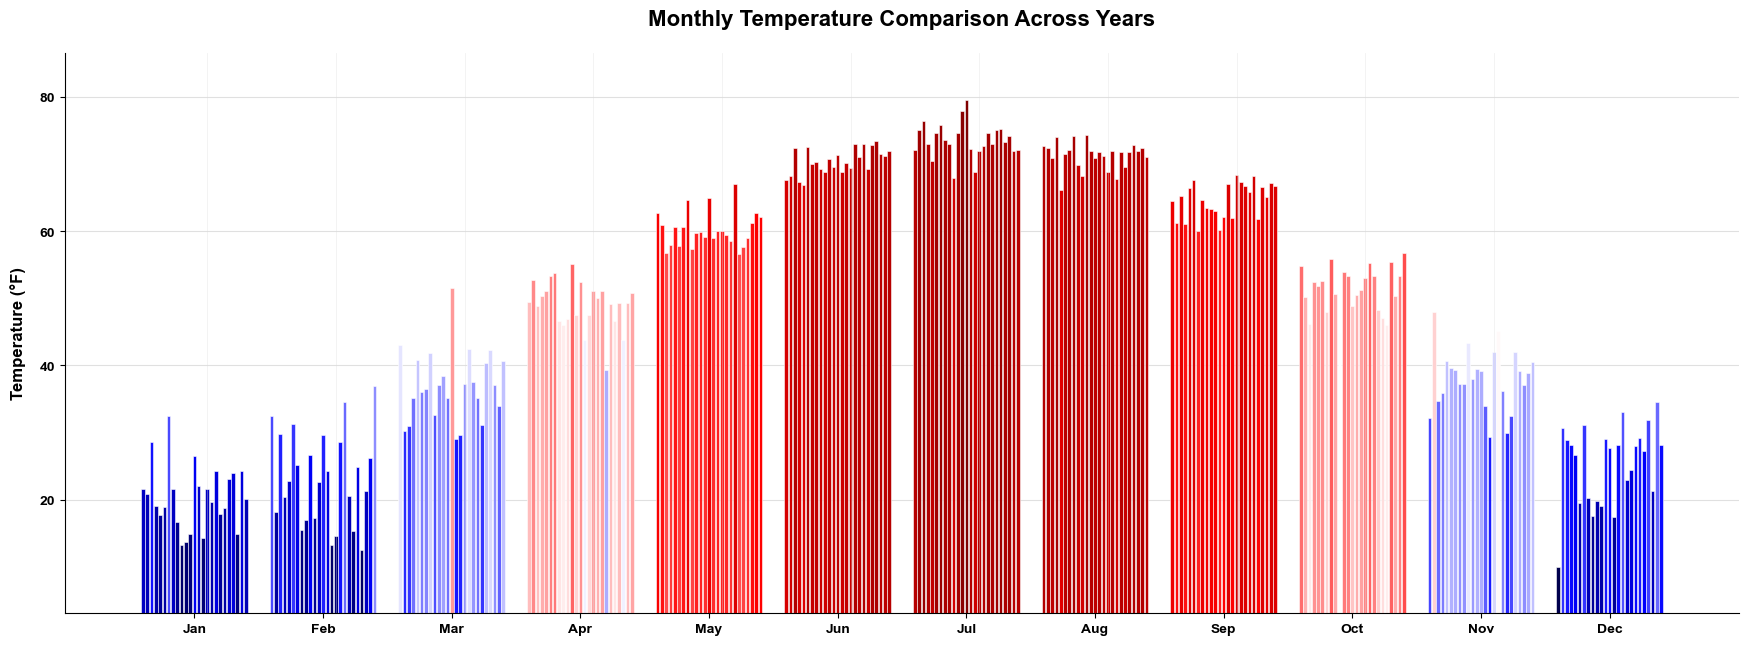

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

# Set font and figure parameters for a more elegant look
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# Read the temperature data
try:
    df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/temperature.csv')
    print(f"Successfully loaded data with shape: {df.shape}")
except Exception as e:
    print(f"Error reading CSV: {e}")
    # Create sample data if there's an issue
    data = {
        'Date': [2000, 2001, 2002],
        'Jan': [21.6, 20.8, 28.6],
        'Feb': [32.5, 18.1, 29.8],
        'Mar': [43.1, 30.2, 31.0],
        'Apr': [49.4, 52.7, 48.9],
        'May': [62.8, 60.9, 56.8],
        'Jun': [67.7, 68.3, 72.4],
        'Jul': [72.2, 75.1, 76.5],
        'Aug': [72.7, 72.5, 70.9],
        'Sep': [64.6, 61.2, 65.3],
        'Oct': [54.8, 50.2, 46.2],
        'Nov': [32.2, 48.0, 34.7],
        'Dec': [10.0, 30.7, 28.9]
    }
    df = pd.DataFrame(data)

# Get the column that contains years and months
year_column = df.columns[0]  # First column (usually "Date")
months = df.columns[1:].tolist()  # All other columns are months

# Create a figure with a better aspect ratio
fig, ax = plt.subplots(figsize=(18, 7))

# Calculate the min and max temperatures for color scaling
all_temps = []
for _, row in df.iterrows():
    all_temps.extend([row[month] for month in months])
min_temp = min(all_temps)
max_temp = max(all_temps)

# Use the seismic colormap - perfect for temperature visualization
# It ranges from blue (cold) through white to red (hot)
cmap = plt.cm.seismic
norm = mcolors.Normalize(vmin=min_temp, vmax=max_temp)

# Create x positions for bars - now grouped by month
total_months = len(months)
years = df[year_column].tolist()
total_years = len(years)
month_width = total_years * 1.2  # Spacing between month groups
bar_width = 0.85

bar_positions = []
bar_heights = []
bar_colors = []
x_tick_positions = []
x_tick_labels = []

# Process data and create positions - now grouped by month instead of year
for month_idx, month in enumerate(months):
    month_start_pos = month_idx * month_width
    x_tick_positions.append(month_start_pos + (total_years - 1) / 2)
    x_tick_labels.append(month)
    
    for year_idx, year in enumerate(years):
        pos = month_start_pos + year_idx
        temp = df.loc[df[year_column] == year, month].values[0]
        
        bar_positions.append(pos)
        bar_heights.append(temp)
        bar_colors.append(cmap(norm(temp)))

# Create the bars
bars = ax.bar(bar_positions, bar_heights, width=bar_width, color=bar_colors, 
              edgecolor='white', linewidth=0.4)

# Set x-axis ticks for months
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, fontweight='bold', color='black')

# Add small year labels inside each month group
if total_years <= 8:  # Only add year labels if there aren't too many years
    for month_idx, month in enumerate(months):
        for year_idx, year in enumerate(years):
            pos = month_idx * month_width + year_idx
            ax.text(pos, -2, str(year), ha='center', va='top', 
                   fontsize=7, alpha=0.7, rotation=90)

# Clean up the plot
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Set y-axis properties
y_padding = (max_temp - min_temp) * 0.1
y_min = max(0, min_temp - y_padding)
y_max = max_temp + y_padding
y_range = y_max - y_min

# Create nice round tick intervals
if y_range <= 25:
    tick_interval = 5
elif y_range <= 50:
    tick_interval = 10
else:
    tick_interval = 20

y_ticks = np.arange(
    np.floor(y_min / tick_interval) * tick_interval,
    np.ceil(y_max / tick_interval) * tick_interval + 0.1, 
    tick_interval
)
ax.set_yticks(y_ticks)
ax.set_ylim(y_min, y_max)

# Add subtle gridlines only on y-axis
ax.yaxis.grid(True, linestyle='-', alpha=0.15, color='#333333')
ax.set_axisbelow(True)

# Add slight visual separation between month groups
for i in range(total_months - 1):
    separator_pos = (i + 1) * month_width - month_width/2
    ax.axvline(x=separator_pos, color='#dddddd', linestyle='-', alpha=0.5, linewidth=0.5)

# Add a title
plt.title('Monthly Temperature Comparison Across Years', fontsize=16, pad=20, fontweight='bold', color='black')

# Set y-axis label
ax.set_ylabel('Temperature (°F)', labelpad=10, fontsize=12, fontweight='bold', color='black')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.98)

# Save with higher quality
# plt.savefig('monthly_temperature_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('Avg_monthly_Temp.png', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='white')

plt.show()

Successfully loaded data with shape: (25, 13)


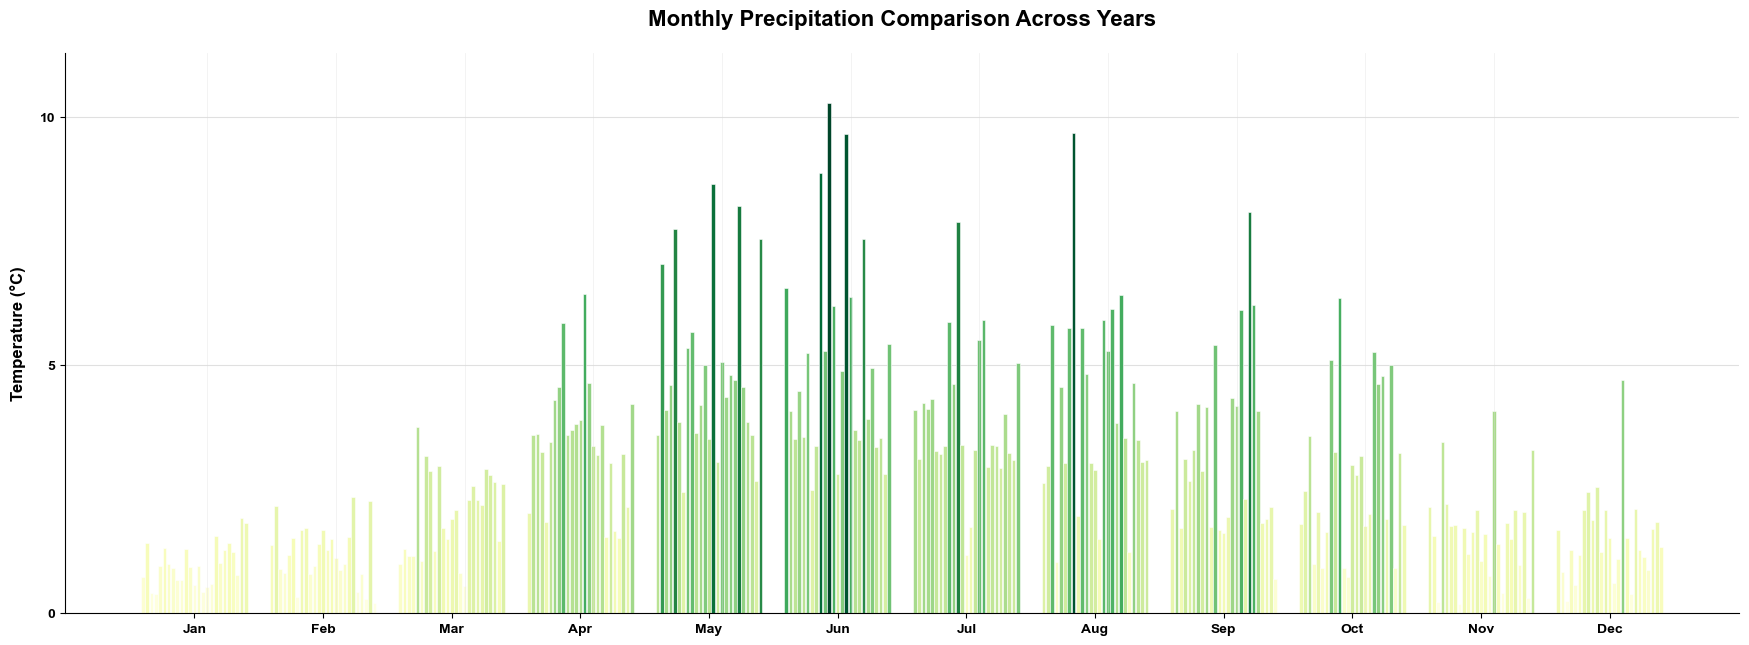

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

# Set font and figure parameters for a more elegant look
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# Read the temperature data
try:
    df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/precipitation.csv')
    print(f"Successfully loaded data with shape: {df.shape}")
except Exception as e:
    print(f"Error reading CSV: {e}")
    # Create sample data if there's an issue
    data = {
        'Date': [2000, 2001, 2002],
        'Jan': [21.6, 20.8, 28.6],
        'Feb': [32.5, 18.1, 29.8],
        'Mar': [43.1, 30.2, 31.0],
        'Apr': [49.4, 52.7, 48.9],
        'May': [62.8, 60.9, 56.8],
        'Jun': [67.7, 68.3, 72.4],
        'Jul': [72.2, 75.1, 76.5],
        'Aug': [72.7, 72.5, 70.9],
        'Sep': [64.6, 61.2, 65.3],
        'Oct': [54.8, 50.2, 46.2],
        'Nov': [32.2, 48.0, 34.7],
        'Dec': [10.0, 30.7, 28.9]
    }
    df = pd.DataFrame(data)

# Get the column that contains years and months
year_column = df.columns[0]  # First column (usually "Date")
months = df.columns[1:].tolist()  # All other columns are months

# Create a figure with a better aspect ratio
fig, ax = plt.subplots(figsize=(18, 7))

# Calculate the min and max temperatures for color scaling
all_temps = []
for _, row in df.iterrows():
    all_temps.extend([row[month] for month in months])
min_temp = min(all_temps)
max_temp = max(all_temps)

# Use the seismic colormap - perfect for temperature visualization
# It ranges from blue (cold) through white to red (hot)
cmap = plt.cm.YlGn
norm = mcolors.Normalize(vmin=min_temp, vmax=max_temp)

# Create x positions for bars - now grouped by month
total_months = len(months)
years = df[year_column].tolist()
total_years = len(years)
month_width = total_years * 1.2  # Spacing between month groups
bar_width = 0.85

bar_positions = []
bar_heights = []
bar_colors = []
x_tick_positions = []
x_tick_labels = []

# Process data and create positions - now grouped by month instead of year
for month_idx, month in enumerate(months):
    month_start_pos = month_idx * month_width
    x_tick_positions.append(month_start_pos + (total_years - 1) / 2)
    x_tick_labels.append(month)
    
    for year_idx, year in enumerate(years):
        pos = month_start_pos + year_idx
        temp = df.loc[df[year_column] == year, month].values[0]
        
        bar_positions.append(pos)
        bar_heights.append(temp)
        bar_colors.append(cmap(norm(temp)))

# Create the bars
bars = ax.bar(bar_positions, bar_heights, width=bar_width, color=bar_colors, 
              edgecolor='white', linewidth=0.4)

# Set x-axis ticks for months
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, fontweight='bold', color='black')

# Add small year labels inside each month group
if total_years <= 8:  # Only add year labels if there aren't too many years
    for month_idx, month in enumerate(months):
        for year_idx, year in enumerate(years):
            pos = month_idx * month_width + year_idx
            ax.text(pos, -2, str(year), ha='center', va='top', 
                   fontsize=7, alpha=0.7, rotation=90)

# Clean up the plot
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Set y-axis properties
y_padding = (max_temp - min_temp) * 0.1
y_min = max(0, min_temp - y_padding)
y_max = max_temp + y_padding
y_range = y_max - y_min

# Create nice round tick intervals
if y_range <= 25:
    tick_interval = 5
elif y_range <= 50:
    tick_interval = 10
else:
    tick_interval = 20

y_ticks = np.arange(
    np.floor(y_min / tick_interval) * tick_interval,
    np.ceil(y_max / tick_interval) * tick_interval + 0.1, 
    tick_interval
)
ax.set_yticks(y_ticks)
ax.set_ylim(y_min, y_max)

# Add subtle gridlines only on y-axis
ax.yaxis.grid(True, linestyle='-', alpha=0.15, color='#333333')
ax.set_axisbelow(True)

# Add slight visual separation between month groups
for i in range(total_months - 1):
    separator_pos = (i + 1) * month_width - month_width/2
    ax.axvline(x=separator_pos, color='#dddddd', linestyle='-', alpha=0.5, linewidth=0.5)

# Add a title
plt.title('Monthly Precipitation Comparison Across Years', fontsize=16, pad=20, fontweight='bold', color='black')

# Set y-axis label
ax.set_ylabel('Temperature (°C)', labelpad=10, fontsize=12, fontweight='bold', color='black')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.98)

# Save with higher quality
plt.savefig('AvgPrecipitation.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\TS\AppData\Local\Temp\ipykernel_18012\2087602379.py:6: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_stock.csv', parse_dates=['Date'], dayfirst=True)


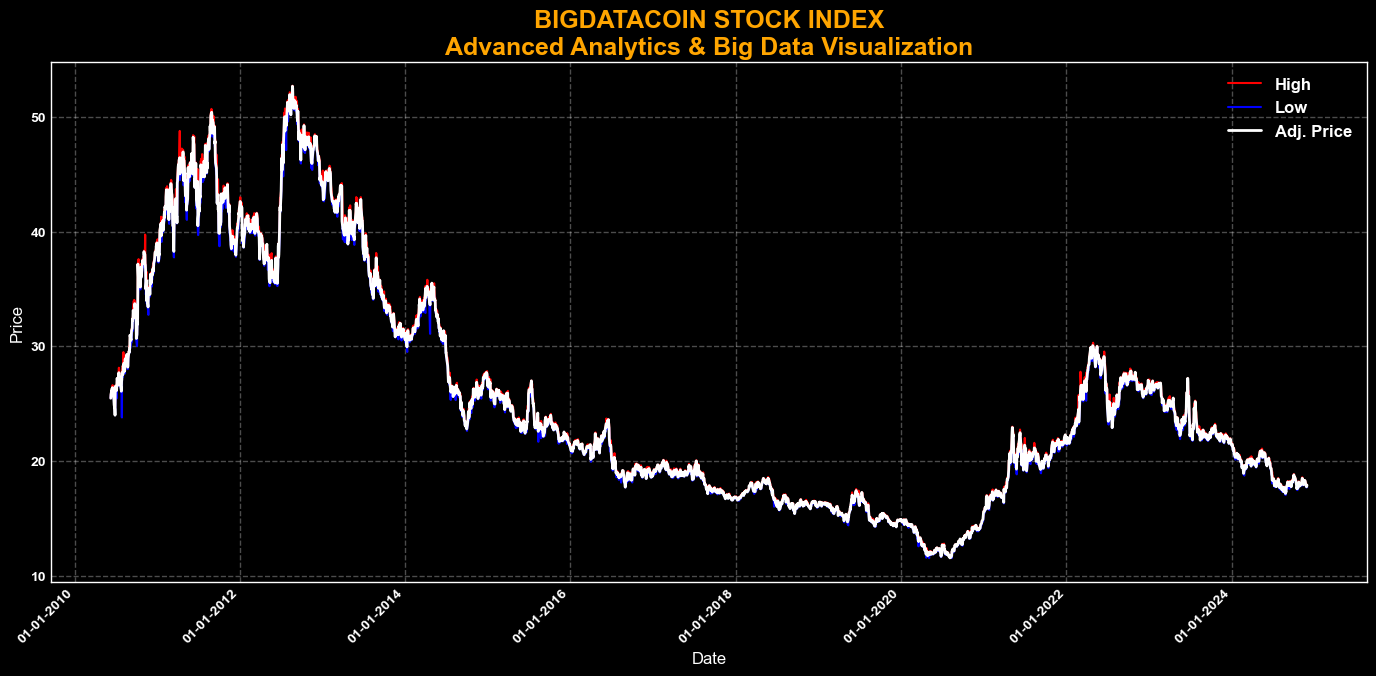

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

# Load your CSV data
df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_stock.csv', parse_dates=['Date'], dayfirst=True)

# Sort by date (optional, for better plotting)
df = df.sort_values('Date')

# Plotting
plt.figure(figsize=(14, 7))
plt.style.use('dark_background')  # Similar to your image

# Plot High and Low as lines
plt.plot(df['Date'], df['High'], color='red', label='High', linewidth=1.5)
plt.plot(df['Date'], df['Low'], color='blue', label='Low', linewidth=1.5)

# Plot Adjusted Price as a white line
plt.plot(df['Date'], df['Price'], color='white', label='Adj. Price', linewidth=2)

# Fill between High and Low for a band effect
plt.fill_between(df['Date'], df['Low'], df['High'], color='gray', alpha=0.2)

# Formatting
plt.title('BIGDATACOIN STOCK INDEX\nAdvanced Analytics & Big Data Visualization', fontsize=18, color='orange', weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(facecolor='black', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

# Date formatting
plt.gca().xaxis.set_major_formatter(DateFormatter('%d-%m-%Y'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


C:\Users\TS\AppData\Local\Temp\ipykernel_18012\2225363332.py:6: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_stock.csv', parse_dates=['Date'], dayfirst=True)


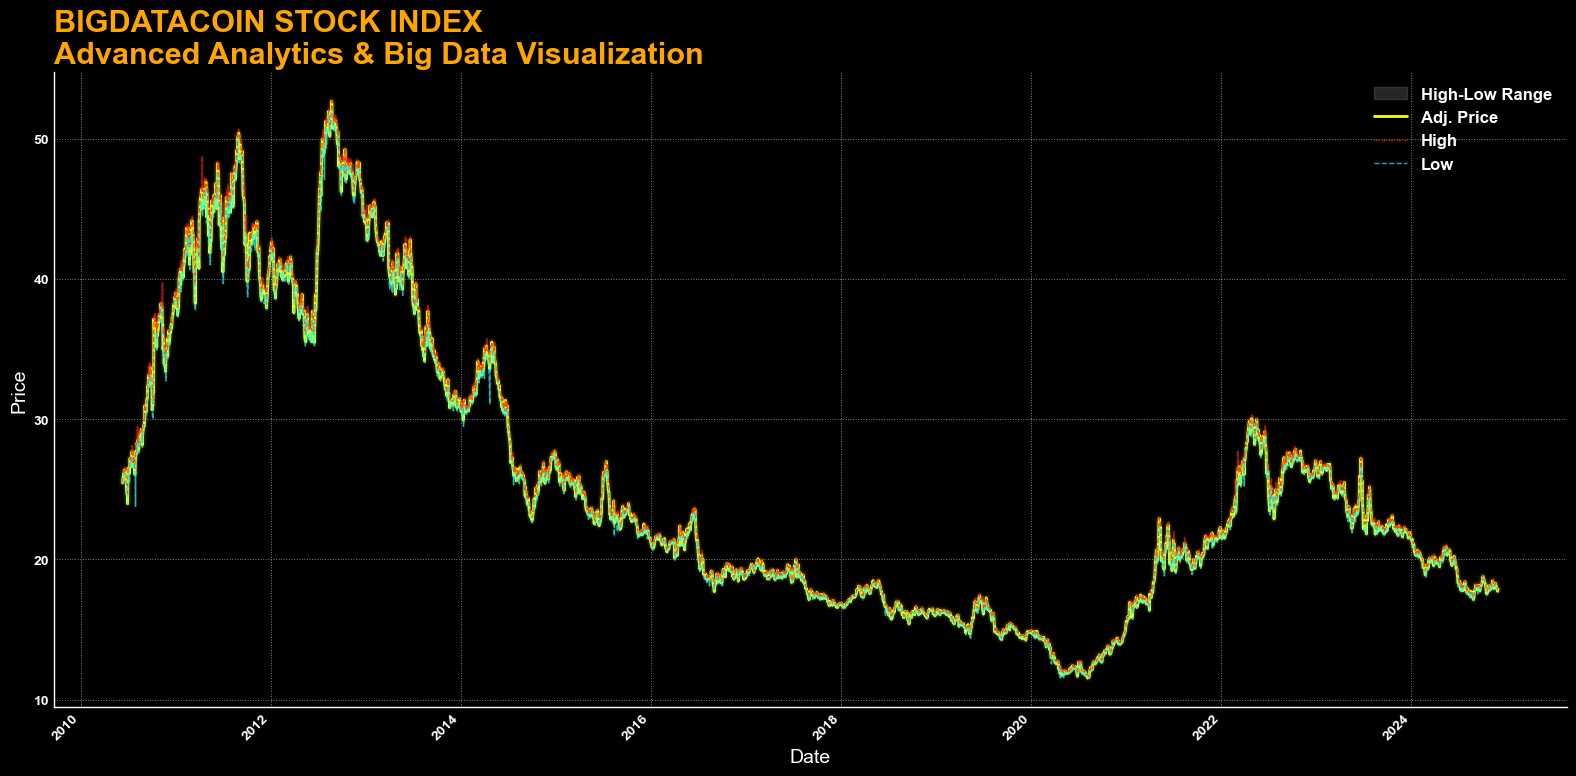

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your CSV data
df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_stock.csv', parse_dates=['Date'], dayfirst=True)
df = df.sort_values('Date')

# Prepare data
dates = df['Date']
high = df['High']
low = df['Low']
adj = df['Price']

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 8))

# Plot high/low as a filled band
ax.fill_between(dates, low, high, color='gray', alpha=0.3, label='High-Low Range')

# Plot adjusted price as a glowing yellow line (multiple lines for glow effect)
for n, alpha in zip([6, 4, 2], [0.05, 0.10, 0.20]):
    ax.plot(dates, adj, color='yellow', linewidth=n, alpha=alpha)
ax.plot(dates, adj, color='yellow', linewidth=2, label='Adj. Price')

# Optionally, plot high/low as dotted lines
ax.plot(dates, high, color='red', linestyle='--', linewidth=1, alpha=0.7, label='High')
ax.plot(dates, low, color='cyan', linestyle='--', linewidth=1, alpha=0.7, label='Low')

# Grid and formatting
ax.grid(True, which='both', linestyle=':', linewidth=0.7, alpha=0.5)
ax.set_title('BIGDATACOIN STOCK INDEX\nAdvanced Analytics & Big Data Visualization', fontsize=22, color='orange', weight='bold', loc='left')
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Price', fontsize=14)
ax.legend(facecolor='black', fontsize=12, loc='upper right')
plt.xticks(rotation=45, ha='right')

# Remove top/right spines for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


C:\Users\TS\AppData\Local\Temp\ipykernel_18012\1105586113.py:6: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_stock.csv', parse_dates=['Date'], dayfirst=True)


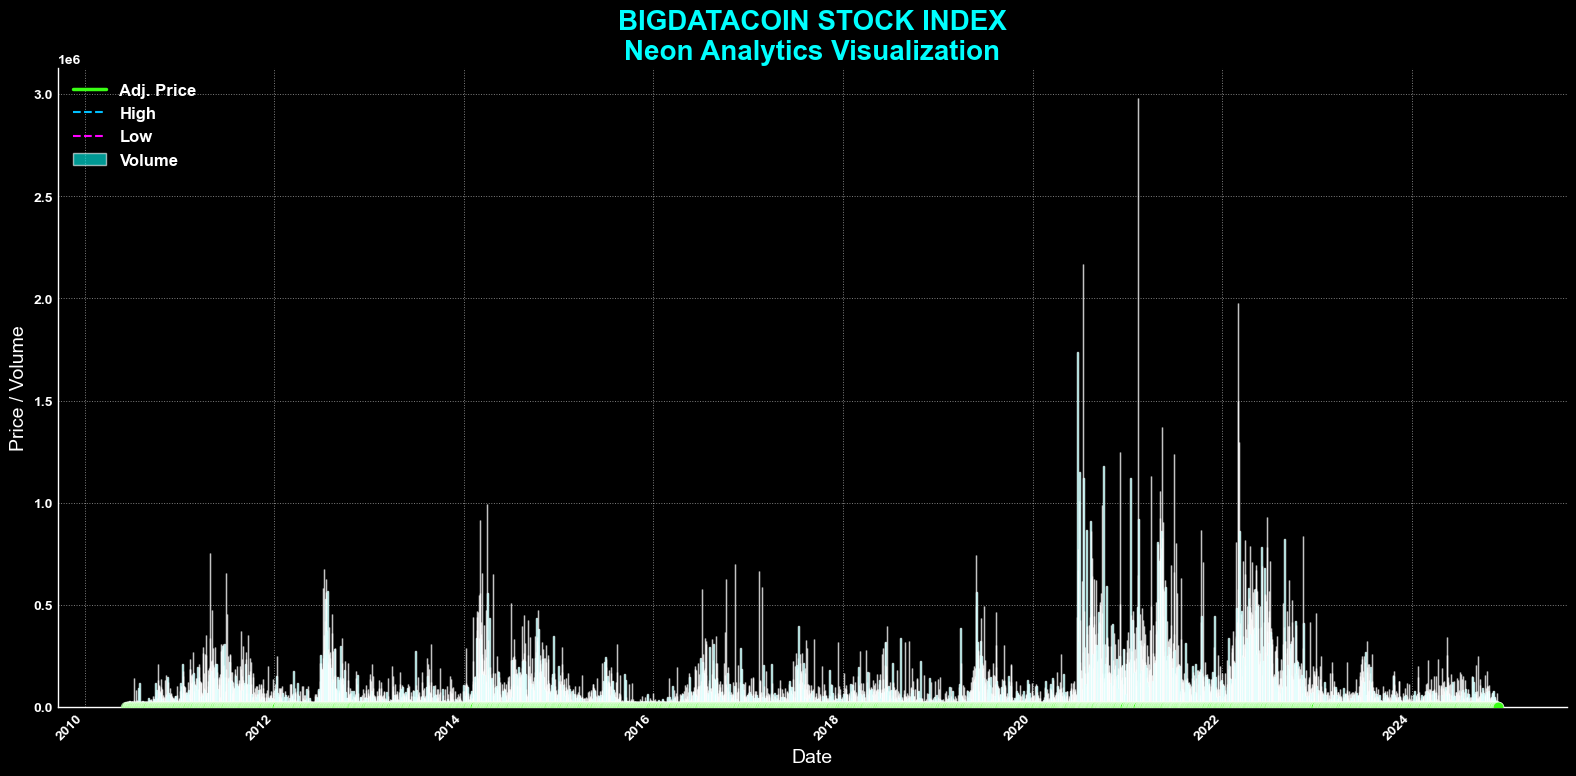

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load your CSV data ---
df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_stock.csv', parse_dates=['Date'], dayfirst=True)
df = df.sort_values('Date')

# Convert volume to numeric (remove 'K', 'M', etc.)
def parse_vol(vol):
    vol = str(vol).replace(',', '').upper()
    if 'K' in vol:
        return float(vol.replace('K', '')) * 1_000
    elif 'M' in vol:
        return float(vol.replace('M', '')) * 1_000_000
    else:
        try:
            return float(vol)
        except:
            return np.nan

df['Vol.'] = df['Vol.'].apply(parse_vol)

# --- Prepare data ---
dates = df['Date']
adj = df['AdjStockPrice']
high = df['High']
low = df['Low']
volume = df['Vol.']

plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(16, 8))

# --- Neon glowing volume bars ---
for n, alpha in zip([8, 6, 4, 2], [0.03, 0.07, 0.15, 0.25]):
    ax1.bar(dates, volume, color='#00fff7', width=0.7, alpha=alpha, zorder=1)
ax1.bar(dates, volume, color='#00fff7', width=0.7, alpha=0.6, zorder=2, label='Volume')

# --- Glowing line for adjusted price ---
for n, alpha in zip([8, 6, 4, 2], [0.05, 0.10, 0.20, 0.35]):
    ax1.plot(dates, adj, color='#39ff14', linewidth=n, alpha=alpha, zorder=3)
ax1.plot(dates, adj, color='#39ff14', linewidth=2.5, zorder=4, label='Adj. Price')

# --- Glowing lines for high/low ---
for n, alpha in zip([6, 4, 2], [0.05, 0.10, 0.25]):
    ax1.plot(dates, high, color='#00bfff', linewidth=n, alpha=alpha, zorder=3)
ax1.plot(dates, high, color='#00bfff', linewidth=1.5, linestyle='--', zorder=4, label='High')

for n, alpha in zip([6, 4, 2], [0.05, 0.10, 0.25]):
    ax1.plot(dates, low, color='#ff00ff', linewidth=n, alpha=alpha, zorder=3)
ax1.plot(dates, low, color='#ff00ff', linewidth=1.5, linestyle='--', zorder=4, label='Low')

# --- Glowing scatter points for adjusted price ---
ax1.scatter(dates, adj, color='#39ff14', s=60, alpha=0.7, zorder=5, edgecolors='white', linewidths=0.5)

# --- Grid, labels, and legend ---
ax1.grid(True, linestyle=':', linewidth=0.7, alpha=0.5)
ax1.set_title('BIGDATACOIN STOCK INDEX\nNeon Analytics Visualization', fontsize=20, color='cyan', weight='bold')
ax1.set_xlabel('Date', fontsize=14)
ax1.set_ylabel('Price / Volume', fontsize=14)
ax1.legend(facecolor='black', fontsize=12, loc='upper left')
plt.xticks(rotation=45, ha='right')

# Remove top/right spines for a modern look
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


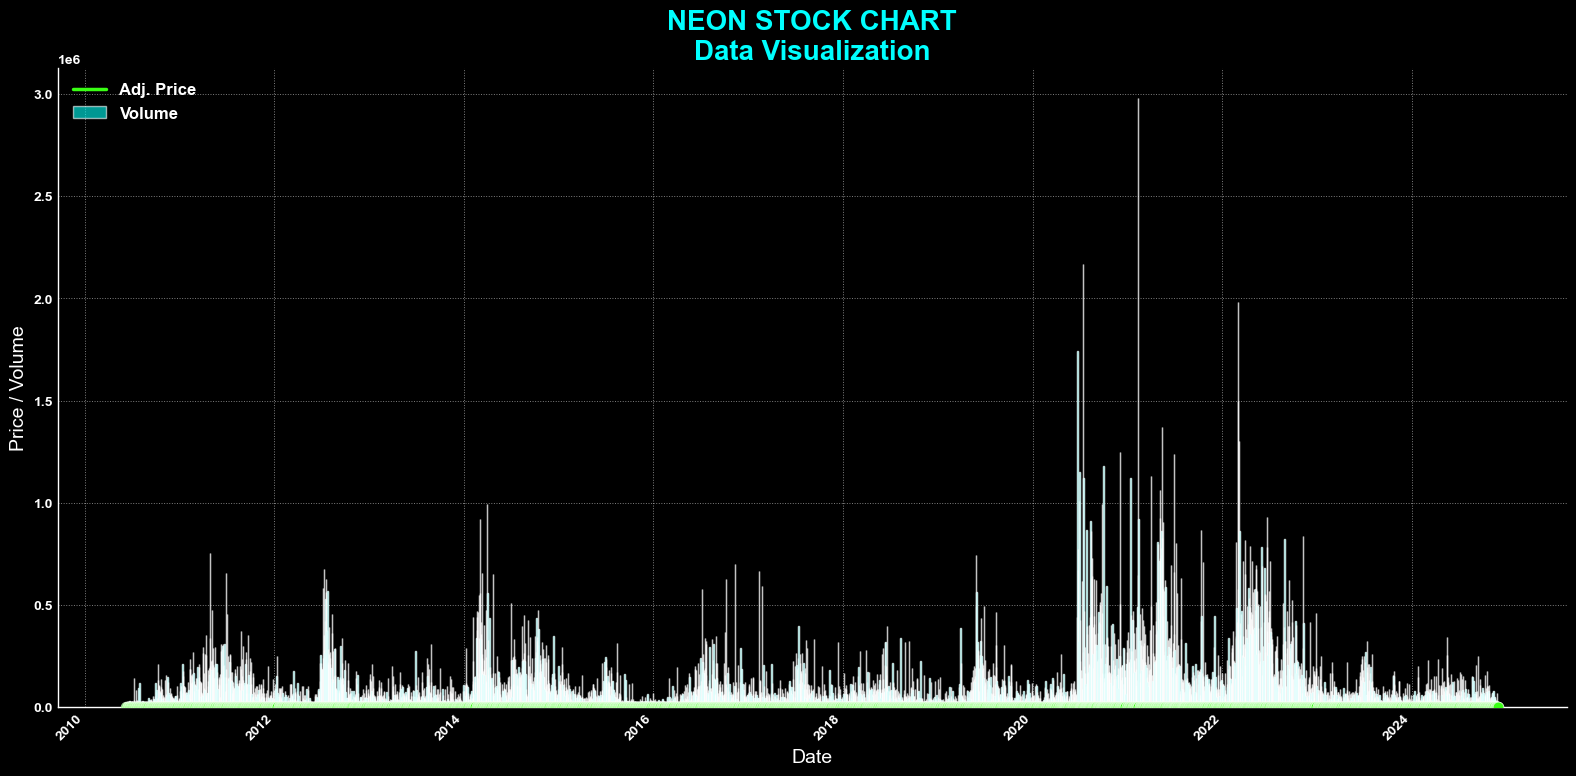

In [63]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Read CSV with correct date parsing ---
df = pd.read_csv(
    'C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_stock.csv',
    parse_dates=['Date'],
    dayfirst=False  # Set to False for 'YYYY-MM-DD'
)
df = df.sort_values('Date')

# --- Parse Volume (handles K and M) ---
def parse_vol(vol):
    vol = str(vol).replace(',', '').upper()
    if 'K' in vol:
        return float(vol.replace('K', '')) * 1_000
    elif 'M' in vol:
        return float(vol.replace('M', '')) * 1_000_000
    else:
        try:
            return float(vol)
        except:
            return np.nan

df['Vol.'] = df['Vol.'].apply(parse_vol)

# --- Data for plotting ---
dates = df['Date']
adj = df['AdjStockPrice']
volume = df['Vol.']

plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(16, 8))

# --- Neon glowing volume bars ---
for n, alpha in zip([8, 6, 4, 2], [0.03, 0.07, 0.15, 0.25]):
    ax1.bar(dates, volume, color='#00fff7', width=0.7, alpha=alpha, zorder=1)
ax1.bar(dates, volume, color='#00fff7', width=0.7, alpha=0.6, zorder=2, label='Volume')

# --- Glowing line for adjusted price ---
for n, alpha in zip([8, 6, 4, 2], [0.05, 0.10, 0.20, 0.35]):
    ax1.plot(dates, adj, color='#39ff14', linewidth=n, alpha=alpha, zorder=3)
ax1.plot(dates, adj, color='#39ff14', linewidth=2.5, zorder=4, label='Adj. Price')

# --- Glowing scatter points for adjusted price ---
ax1.scatter(dates, adj, color='#39ff14', s=60, alpha=0.7, zorder=5, edgecolors='white', linewidths=0.5)

# --- Grid, labels, and legend ---
ax1.grid(True, linestyle=':', linewidth=0.7, alpha=0.5)
ax1.set_title('NEON STOCK CHART\nData Visualization', fontsize=20, color='cyan', weight='bold')
ax1.set_xlabel('Date', fontsize=14)
ax1.set_ylabel('Price / Volume', fontsize=14)
ax1.legend(facecolor='black', fontsize=12, loc='upper left')
plt.xticks(rotation=45, ha='right')

# Remove top/right spines for a modern look
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


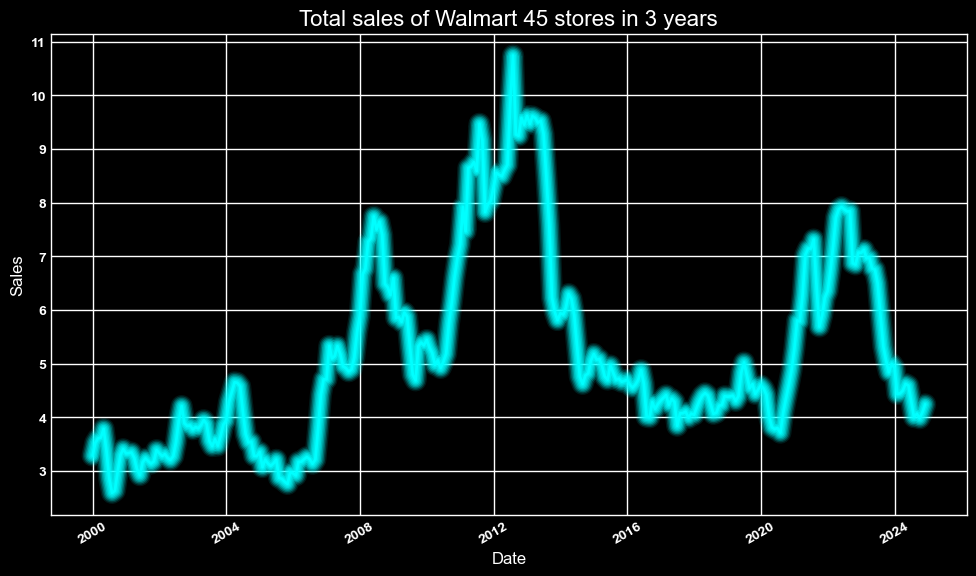

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Read your data
df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_price.csv', parse_dates=['Date'])

# Sort by date if not already sorted
df = df.sort_values('Date')

plt.style.use('dark_background')  # For a dark theme

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the glow effect by drawing the line multiple times
for n in range(1, 8):
    ax.plot(df['Date'], df['AdjPrice'],
            linewidth=2 + n*2,
            alpha=0.03 + 0.07*(8-n),
            color='cyan')

# Plot the main line
ax.plot(df['Date'], df['AdjPrice'], color='cyan', linewidth=2)

# Titles and labels
plt.title('Total sales of Walmart 45 stores in 3 years')
plt.xlabel('Date')
plt.ylabel('Sales')

# Optional: Rotate x-axis labels for readability
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


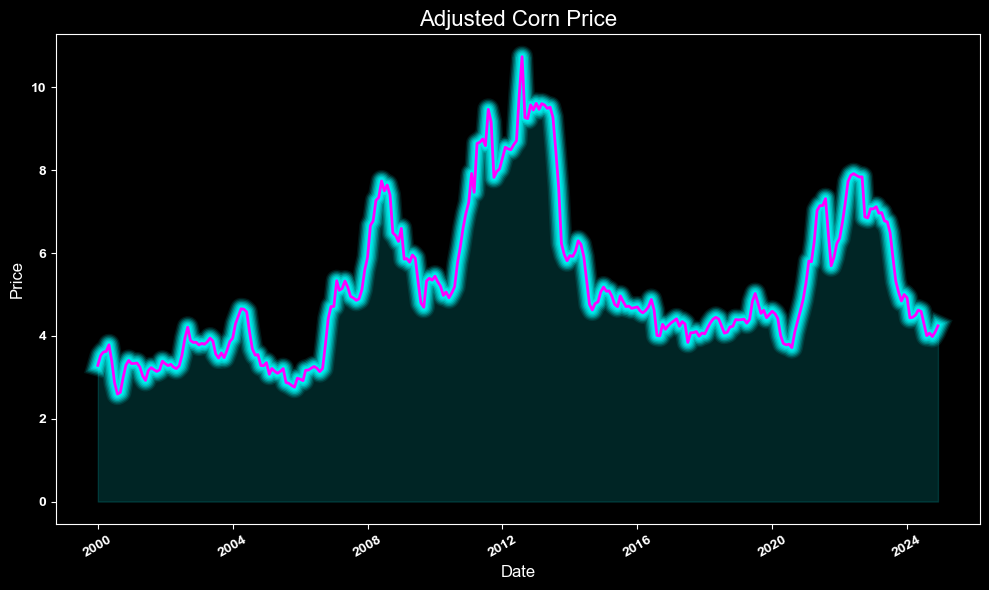

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

# Read your data
df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_price.csv', parse_dates=['Date'])
df = df.sort_values('Date')

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))

# Glow effect for the line
for n in range(1, 8):
    ax.plot(df['Date'], df['AdjPrice'],
            linewidth=2 + n*2,
            alpha=0.03 + 0.07*(8-n),
            color='cyan')

# Main line
ax.plot(df['Date'], df['AdjPrice'], color='magenta', linewidth=2)

# Fill below the line for the glow effect
ax.fill_between(df['Date'], df['AdjPrice'], color='cyan', alpha=0.15)

# Titles and labels
plt.title('Adjusted Corn Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('AdjCornPrice.png', dpi=300, bbox_inches='tight')
plt.show()


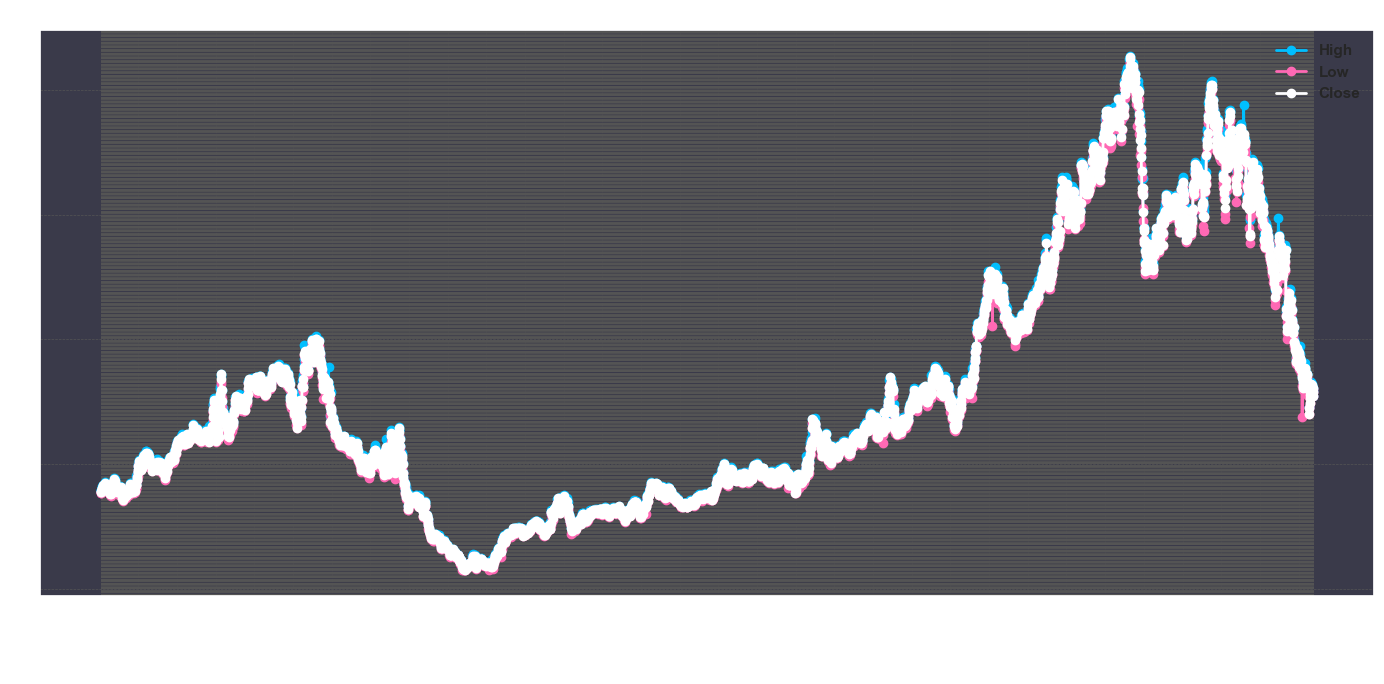

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read your stock data
df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_stock.csv')

# Make sure your CSV has columns: 'Date', 'High', 'Low', 'Close'
# If not, adjust column names below accordingly

# Prepare the plot
plt.figure(figsize=(14, 7))
sns.set(style="darkgrid")

# Plot High and Low lines
plt.plot(df['Date'], df['High'], color='#00bfff', linewidth=2, marker='o', label='High')
plt.plot(df['Date'], df['Low'], color='#ff69b4', linewidth=2, marker='o', label='Low')
plt.plot(df['Date'], df['Price'], color='white', linewidth=2, marker='o', label='Close', zorder=10)

# Fill between High and Close (above close)
plt.fill_between(df['Date'], df['High'], df['Price'],
                 where=(df['High'] > df['Price']),
                 interpolate=True, color='#00bfff', alpha=0.3)

# Fill between Low and Close (below close)
plt.fill_between(df['Date'], df['Low'], df['Price'],
                 where=(df['Low'] < df['Price']),
                 interpolate=True, color='#ff69b4', alpha=0.3)

# Improve visual style
plt.gca().set_facecolor('#3a3a4a')
plt.grid(color='#555', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')
plt.legend(facecolor='#3a3a4a', edgecolor='white')
plt.title('Stock High, Low, and Close with Shaded Areas', color='white')
plt.tight_layout()
plt.show()


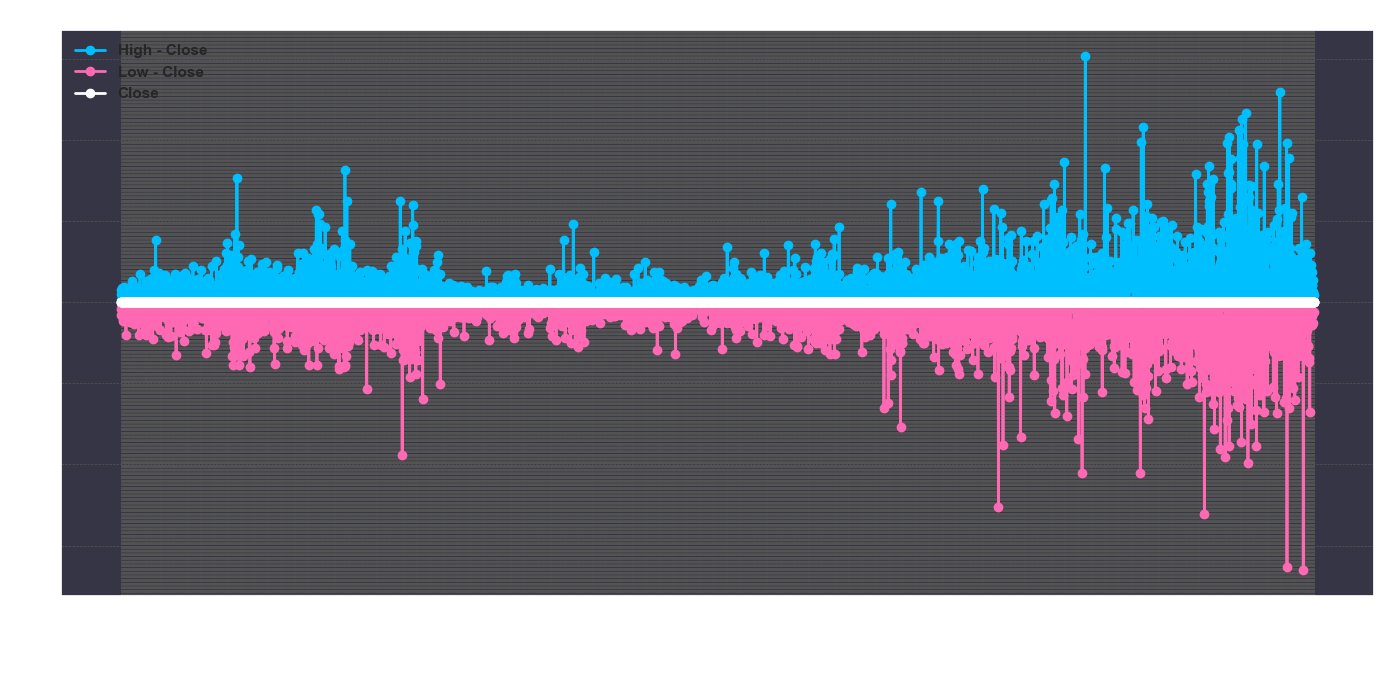

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read your stock data
df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/adjusted_stock.csv')

# Calculate differences from Close
df['HighDiff'] = df['High'] - df['Price']
df['LowDiff'] = df['Low'] - df['Price']
df['CloseDiff'] = 0  # Always zero

# Prepare the plot
plt.figure(figsize=(14, 7))
sns.set(style="darkgrid")

# Plot High and Low difference lines
plt.plot(df['Date'], df['HighDiff'], color='#00bfff', linewidth=2, marker='o', label='High - Close')
plt.plot(df['Date'], df['LowDiff'], color='#ff69b4', linewidth=2, marker='o', label='Low - Close')
plt.plot(df['Date'], df['CloseDiff'], color='white', linewidth=2, marker='o', label='Close', zorder=10)

# Fill between HighDiff and zero (above close)
plt.fill_between(df['Date'], df['HighDiff'], 0,
                 where=(df['HighDiff'] > 0),
                 interpolate=True, color='#00bfff', alpha=0.5)

# Fill between LowDiff and zero (below close)
plt.fill_between(df['Date'], df['LowDiff'], 0,
                 where=(df['LowDiff'] < 0),
                 interpolate=True, color='#ff69b4', alpha=0.5)

# Improve visual style
plt.gca().set_facecolor('#353545')
plt.grid(color='#555', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')
plt.legend(facecolor='#353545', edgecolor='white')
plt.title('Stock High/Low Deviations from Close', color='white')
plt.ylabel('Difference from Close', color='white')
plt.tight_layout()
plt.show()


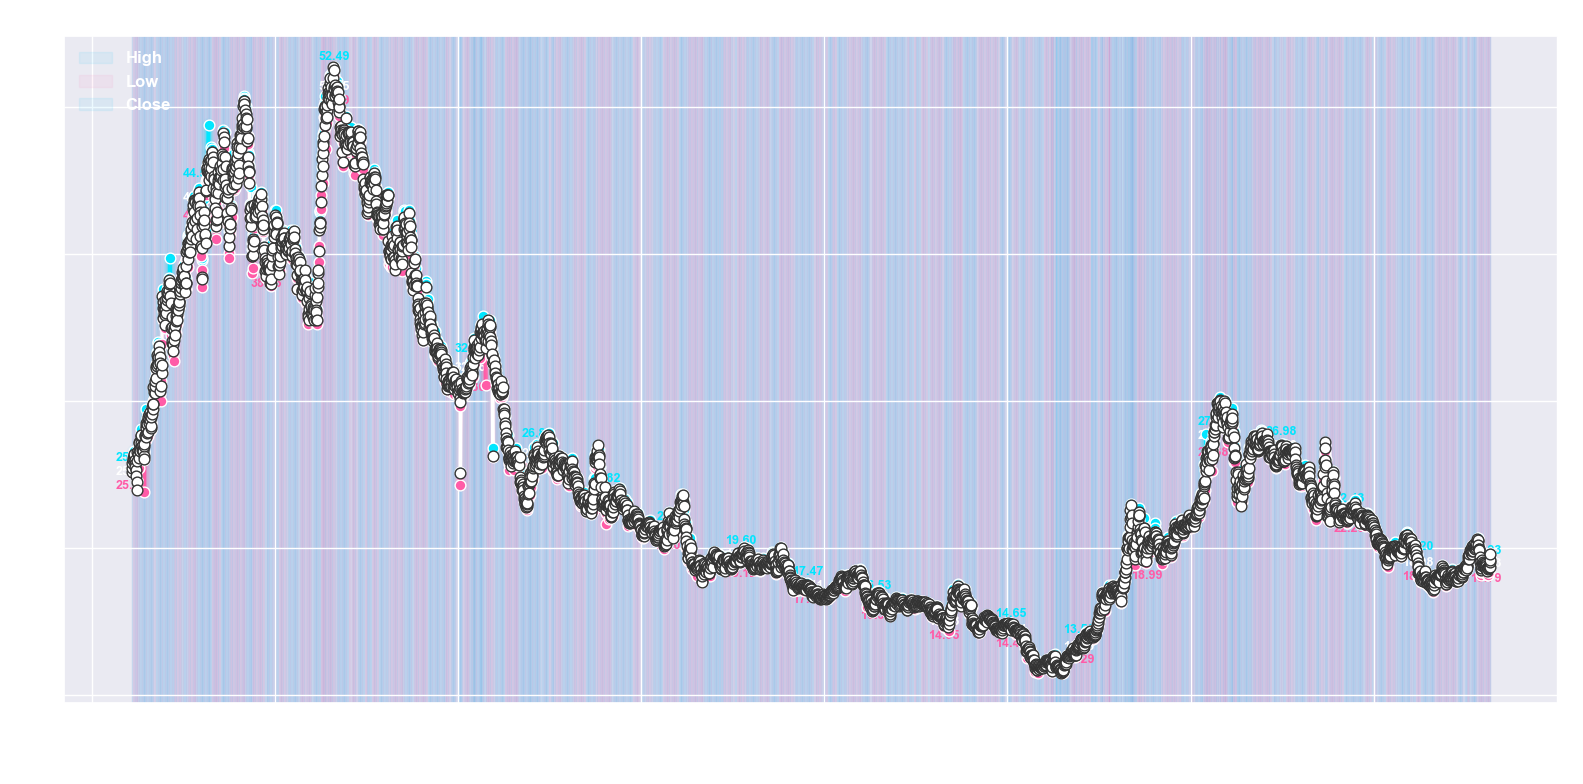

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read your stock data
df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/stock_data.csv')
# Ensure columns: 'Date', 'High', 'Low', 'Close', 'Volume'
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Normalize volume for band opacity
vol_norm = (df['Volume'] - df['Volume'].min()) / (df['Volume'].max() - df['Volume'].min())

fig, ax = plt.subplots(figsize=(16, 8))
plt.style.use('dark_background')

# Plot volume bands
for i, (date, norm) in enumerate(zip(df['Date'], vol_norm)):
    ax.axvspan(date - pd.Timedelta(hours=12), date + pd.Timedelta(hours=12),
               color='#00bfff' if i % 2 == 0 else '#ff69b4', alpha=0.07 + 0.18 * norm, zorder=0)

# Glow effect function
def plot_glow(x, y, color, linewidth=2, alpha=1, zorder=2):
    for lw, a in zip([10, 8, 6, 4], [0.03, 0.08, 0.15, 0.25]):
        ax.plot(x, y, color=color, linewidth=lw, alpha=a, zorder=zorder)
    ax.plot(x, y, color=color, linewidth=linewidth, alpha=alpha, zorder=zorder+1)

# Plot high, low, close with glow
plot_glow(df['Date'], df['High'], '#00e6ff', linewidth=2.5, alpha=1, zorder=3)
plot_glow(df['Date'], df['Low'], '#ff5ca7', linewidth=2.5, alpha=1, zorder=3)
plot_glow(df['Date'], df['Close'], 'white', linewidth=2.5, alpha=1, zorder=4)

# Fill between close and high (blue glow)
ax.fill_between(df['Date'], df['Close'], df['High'],
                where=(df['High'] > df['Close']),
                color='#00e6ff', alpha=0.25, zorder=2)

# Fill between close and low (pink glow)
ax.fill_between(df['Date'], df['Close'], df['Low'],
                where=(df['Low'] < df['Close']),
                color='#ff5ca7', alpha=0.25, zorder=2)

# Scatter points with white edge
ax.scatter(df['Date'], df['High'], color='#00e6ff', edgecolor='white', s=60, zorder=5)
ax.scatter(df['Date'], df['Low'], color='#ff5ca7', edgecolor='white', s=60, zorder=5)
ax.scatter(df['Date'], df['Close'], color='white', edgecolor='#333', s=60, zorder=6)

# Add value labels (optional: only show every Nth to avoid clutter)
for i in range(0, len(df), max(1, len(df)//20)):
    ax.text(df['Date'].iloc[i], df['High'].iloc[i]+0.5, f"{df['High'].iloc[i]:.2f}", color='#00e6ff', fontsize=9, ha='center', va='bottom')
    ax.text(df['Date'].iloc[i], df['Low'].iloc[i]-0.5, f"{df['Low'].iloc[i]:.2f}", color='#ff5ca7', fontsize=9, ha='center', va='top')
    ax.text(df['Date'].iloc[i], df['Close'].iloc[i], f"{df['Close'].iloc[i]:.2f}", color='white', fontsize=9, ha='center', va='center')

# Labels and legend
ax.set_title('Stock High, Low, Close with Volume Bands', color='white', fontsize=18)
ax.set_xlabel('Date', color='white', fontsize=14)
ax.set_ylabel('Price', color='white', fontsize=14)
ax.tick_params(axis='x', colors='white', rotation=45)
ax.tick_params(axis='y', colors='white')
ax.legend(['High', 'Low', 'Close'], loc='upper left', facecolor='#222', edgecolor='white', fontsize=12)

plt.tight_layout()
plt.show()


In [89]:
import pandas as pd
import mplfinance as mpf

# Read your OHLC data
df = pd.read_csv('C://Users/TS/Desktop/info-526/trend-setters/project-2-trend-setters/data/stock_data.csv', parse_dates=['Date'], index_col='Date', dayfirst=True)

# Ensure columns: 'Open', 'High', 'Low', 'Close', (optional: 'Volume')

# Custom style similar to your reference
my_style = mpf.make_mpf_style(
    base_mpf_style='nightclouds',  # Dark, elegant base
    marketcolors=mpf.make_marketcolors(
        up='#00e6ff',    # Neon blue for up candles
        down='#ff5ca7',  # Neon pink for down candles
        edge='inherit',
        wick='white',
        volume='in'
    ),
    rc={
        'axes.labelcolor': 'white',
        'xtick.color': 'white',
        'ytick.color': 'white',
        'axes.edgecolor': '#444',
        'figure.facecolor': '#353545',
        'axes.facecolor': '#353545',
        'savefig.facecolor': '#353545'
    },
    gridcolor='#555',
    gridstyle='--'
)

# Plot the candlestick chart
mpf.plot(
    df,
    type='candle',
    style=my_style,
    title='Candlestick Chart',
    ylabel='Price',
    ylabel_lower='Volume',
    volume=True,            # Show volume bars
    mav=(5, 10),            # Moving averages (optional)
    figratio=(16, 8),
    figscale=1.2,
    tight_layout=True,
    xrotation=20,
    datetime_format='%b %d',
    savefig='candlestick_chart.png'
)


C:\Users\TS\anaconda3\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


In [78]:
pip install mplfinance